In [2]:
import math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from ortools.constraint_solver import routing_enums_pb2
from ortools.constraint_solver import pywrapcp

In [3]:
# STEP 1: DEFINE JOB SITES WITH COORDINATES
# ------------------------------------------------------------
LOCATIONS = {
    "names": [
        "Depot (HQ)",        # 0
        "Site A",            # 1
        "Site B",            # 2
        "Site C",            # 3
        "Site D",            # 4
        "Site E",            # 5
        "Site F",            # 6
        "Site G",            # 7
        "Site H",            # 8
        "Site I",            # 9
        "Site J",            # 10
    ],
    "coordinates": [
        (5,  5),   # 0 Depot
        (2,  9),   # 1 Site A
        (8,  9),   # 2 Site B
        (1,  6),   # 3 Site C
        (9,  6),   # 4 Site D
        (3,  3),   # 5 Site E
        (7,  3),   # 6 Site F
        (4,  7),   # 7 Site G
        (6,  7),   # 8 Site H
        (4,  4),   # 9 Site I
        (6,  4),   # 10 Site J
    ],
    "demands": [0, 2, 4, 3, 5, 2, 4, 3, 2, 4, 3],
    
}

In [4]:
# STEP 2: COMPUTE DISTANCE MATRIX FROM COORDINATES
# ------------------------------------------------------------
def compute_distance_matrix(coordinates):
    n = len(coordinates)
    matrix = []
    for i in range(n):
        row = []
        for j in range(n):
            x1, y1 = coordinates[i]
            x2, y2 = coordinates[j]
            # Euclidean distance, scaled x100 to preserve decimal precision
            dist = math.hypot(x2 - x1, y2 - y1) * 100
            row.append(int(dist))
        matrix.append(row)
    return matrix

#A Shortened form of the function above
'''def create_distance_matrix(coordinates):
    return [
        [int(math.hypot(x2 - x1, y2 - y1) * 100) for x2, y2 in coordinates] for x1, y1 in coordinates
    ]''' 

'def create_distance_matrix(coordinates):\n    return [\n        [int(math.hypot(x2 - x1, y2 - y1) * 100) for x2, y2 in coordinates] for x1, y1 in coordinates\n    ]'

In [5]:
# STEP 3: BUILD THE DATA MODEL
# ------------------------------------------------------------
def create_data_model():
    data = {}
    data["coordinates"]      = LOCATIONS["coordinates"]
    data["names"]            = LOCATIONS["names"]
    data["demands"]          = LOCATIONS["demands"]
    data["distance_matrix"]  = compute_distance_matrix(data["coordinates"])
    data["vehicle_capacities"] = [14, 14, 14]
    data["num_vehicles"]     = 3
    data["depot"]            = 0
    return data


In [6]:
# STEP 7: SOLVE
# ------------------------------------------------------------
data = create_data_model()

manager = pywrapcp.RoutingIndexManager(
        len(data["distance_matrix"]),
        data["num_vehicles"],
        data["depot"]
    )
routing = pywrapcp.RoutingModel(manager)


In [13]:
# STEP 4: EXTRACT ROUTES FROM SOLUTION
# ------------------------------------------------------------
def extract_routes(data, manager, routing, solution):
    """
    Pulls each vehicle's route out of the OR-Tools solution
    and returns a list of route dicts with nodes, distances, loads.
    """
    routes = []
    for vehicle_id in range(data["num_vehicles"]):
        index = routing.Start(vehicle_id)
        route_nodes = []
        route_distance = 0
        route_load = 0

        while not routing.IsEnd(index):
            node = manager.IndexToNode(index)
            route_nodes.append(node)
            route_load += data["demands"][node]
            prev = index
            index = solution.Value(routing.NextVar(index))
            route_distance += routing.GetArcCostForVehicle(prev, index, vehicle_id)

        route_nodes.append(0)  # return to depot
        routes.append({
            "vehicle_id": vehicle_id,
            "nodes": route_nodes,
            "distance": route_distance,
            "load": route_load,
            "capacity": data["vehicle_capacities"][vehicle_id],
        })
    return routes

In [14]:
# STEP 5: PRINT SOLUTION TO CONSOLE
# ------------------------------------------------------------
def print_solution(data, routes):
    print("\n" + "="*55)
    print("  CVRP SOLUTION — Coordinates-based")
    print("="*55)
    total_distance = 0

    for r in routes:
        site_names = [data["names"][n] for n in r["nodes"]]
        print(f"\n  Vehicle {r['vehicle_id'] + 1}:")
        print(f"     Route   : {' -> '.join(site_names)}")
        print(f"     Distance: {r['distance'] / 100:.2f} units")
        print(f"     Load    : {r['load']} / {r['capacity']} units")
        total_distance += r["distance"]

    print("\n" + "-"*55)
    print(f"  Total distance: {total_distance / 100:.2f} units")
    print("="*55 + "\n")


In [15]:
    # Distance callback
def distance_callback(from_index, to_index):
    return data["distance_matrix"][manager.IndexToNode(from_index)][manager.IndexToNode(to_index)]

transit_index = routing.RegisterTransitCallback(distance_callback)
routing.SetArcCostEvaluatorOfAllVehicles(transit_index)

    # Capacity constraint
def demand_callback(from_index):
    return data["demands"][manager.IndexToNode(from_index)]

demand_index = routing.RegisterUnaryTransitCallback(demand_callback)

routing.AddDimensionWithVehicleCapacity(
    demand_index, 0,
    data["vehicle_capacities"],
    True, "Capacity"
    )


True

MATLPLOTLIB CODE FOR VISUALIZATION ON A 2D GRAPH

In [16]:
# STEP 6: VISUALIZE ROUTES ON A MAP
# ------------------------------------------------------------
def visualize_routes(data, routes):
    """
    Plots each vehicle's route on a 2D coordinate map.
    - Depot shown as a star
    - Job sites shown as circles with demand labels
    - Each vehicle's route drawn in a different color
    """
    fig, ax = plt.subplots(figsize=(9, 8))
    colors = ["red", "pink", "green"]   # blue, orange, green
    coords = data["coordinates"]

    # Draw routes
    for r in routes:
        color = colors[r["vehicle_id"]]
        nodes = r["nodes"]
        for i in range(len(nodes) - 1):
            x1, y1 = coords[nodes[i]]
            x2, y2 = coords[nodes[i + 1]]
            ax.annotate("",
                xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(
                    arrowstyle="->",
                    color=color,
                    lw=2.0,
                    connectionstyle="arc3,rad=0.07")
            )

    # Draw depot
    dx, dy = coords[0]
    ax.plot(dx, dy, marker="*", markersize=18, color="red",
            markeredgecolor="cyan", zorder=5)
    ax.annotate(
        data["names"][0],
        (dx, dy), textcoords="offset points", xytext=(8, 8),
        fontsize=9, fontweight="bold", color="blue"
    )

    # Draw job sites
    for i in range(1, len(coords)):
        x, y = coords[i]
        ax.plot(x, y, "o", markersize=14, color="pink",
                markeredgecolor="indigo", markeredgewidth=1.5, zorder=4)
        ax.text(x, y, str(data["demands"][i]),
                ha="center", va="center", fontsize=8,
                fontweight="bold", color="green", zorder=5)
        ax.annotate(
            data["names"][i],
            (x, y), textcoords="offset points", xytext=(8, 6),
            fontsize=8, color="violet"
        )

    # Legend
    legend_handles = [
        mpatches.Patch(color=colors[r["vehicle_id"]],
                       label=f"Vehicle {r['vehicle_id']+1}  |  "
                             f"load: {r['load']}/{r['capacity']}  |  "
                             f"dist: {r['distance']/100:.1f}")
        for r in routes
    ]
    ax.legend(handles=legend_handles, loc="lower right",
              fontsize=9, framealpha=0.9)

    ax.set_title(
        "CVRP Route Map — Engineering Fleet\n"
        "(circle numbers = site demand, star = depot)",
        fontsize=12, pad=14
    )
    ax.set_xlabel("X coordinate")
    ax.set_ylabel("Y coordinate")
    ax.set_xlim(0, 11)
    ax.set_ylim(0, 11)
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.set_aspect("equal")

    plt.tight_layout()
    plt.savefig("cvrp_routes.png", dpi=150, bbox_inches="tight")
    print("  Route map saved as: cvrp_routes.png\n")
    plt.show()

Solving CVRP with coordinates...

  CVRP SOLUTION — Coordinates-based

  Vehicle 1:
     Route   : Depot (HQ) -> Site H -> Site B -> Site D -> Depot (HQ)
     Distance: 12.33 units
     Load    : 11 / 14 units

  Vehicle 2:
     Route   : Depot (HQ) -> Site J -> Site F -> Depot (HQ)
     Distance: 5.64 units
     Load    : 7 / 14 units

  Vehicle 3:
     Route   : Depot (HQ) -> Site G -> Site A -> Site C -> Site E -> Site I -> Depot (HQ)
     Distance: 14.63 units
     Load    : 14 / 14 units

-------------------------------------------------------
  Total distance: 32.60 units

  Route map saved as: cvrp_routes.png



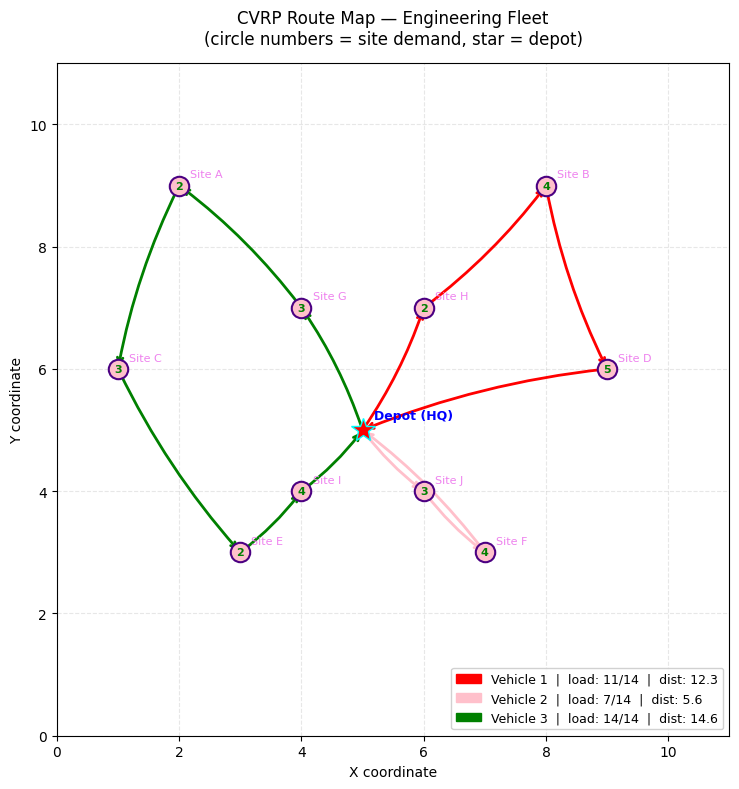

In [17]:
    # Search strategy
search_params = pywrapcp.DefaultRoutingSearchParameters()
search_params.first_solution_strategy = (
    routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
)
search_params.local_search_metaheuristic = (
    routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
)
search_params.time_limit.seconds = 2

print("Solving CVRP with coordinates...")
solution = routing.SolveWithParameters(search_params)

if solution:
    routes = extract_routes(data, manager, routing, solution)
    print_solution(data, routes)
    visualize_routes(data, routes)
else:
    print("No solution found. Try adjusting vehicle capacities.")
